# Q_MLP — Quantile MLP for RUL Prediction

MLP — no recurrence, treats window as flat feature vector.
If Q-MLP ≈ Q-LSTM, temporal structure is not helping for quantile prediction.

**Structure:** Same as DL notebooks (MLP.ipynb, GRU.ipynb, etc.) but:
- Loss: **Pinball loss** instead of NASA asymmetric loss
- Output: **3 neurons** (Q10, Q50, Q90) instead of 1
- Evaluation: Q50 used for RMSE/NASA; Q10-Q90 interval for uncertainty quantification

## 1. Imports & Setup

In [ ]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


## 2. Load Data

In [2]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...


## 3. Build Sliding Windows (30-cycle, engine-split 80/20)

In [3]:
X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)
X_test,  y_test  = build_windows(test_df, FEAT_COLS, is_test=True)
print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

Train engines: 199  Val engines: 50
X_train: (42725, 30, 48)  X_val: (50, 30, 48)
X_train: (42725, 30, 48)  X_val: (50, 30, 48)  X_test: (248, 30, 48)


## 4. DataLoaders

In [4]:
train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)

Train batches: 334  Val batches: 1


## 5. Model Definition — QuantileMLP

In [ ]:
from src.models.dl_architectures import QuantileMLP


## 6. Training with Pinball Loss

  [Q_MLP] Epoch  10 | train=3.9473 | val=2.0269 | best=1.5666  [Pinball]
  [Q_MLP] Early stop at epoch 14


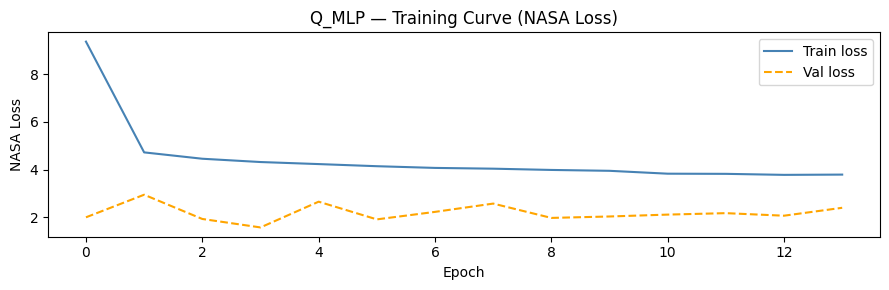

In [6]:
model, train_losses, val_losses = train_quantile_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    quantiles    = QUANTILES,
    epochs       = EPOCHS,
    lr           = LR,
    model_name   = 'Q_MLP',
)
plot_loss_curves(train_losses, val_losses, model_name='Q_MLP')

## 7. Evaluation — Point Metrics (Q50) + Interval Metrics


=== Q_MLP ===
  [Q_MLP (Q50)] RMSE: 16.0724  |  NASA Score: 1085.90 (mean: 4.38)  |  R2: 0.8602  |  Bias: -4.50 (early ↓)
  Interval width (Q90-Q10) mean : 36.43 cycles
  80% interval coverage         : 87.9%  (target: ~80%)


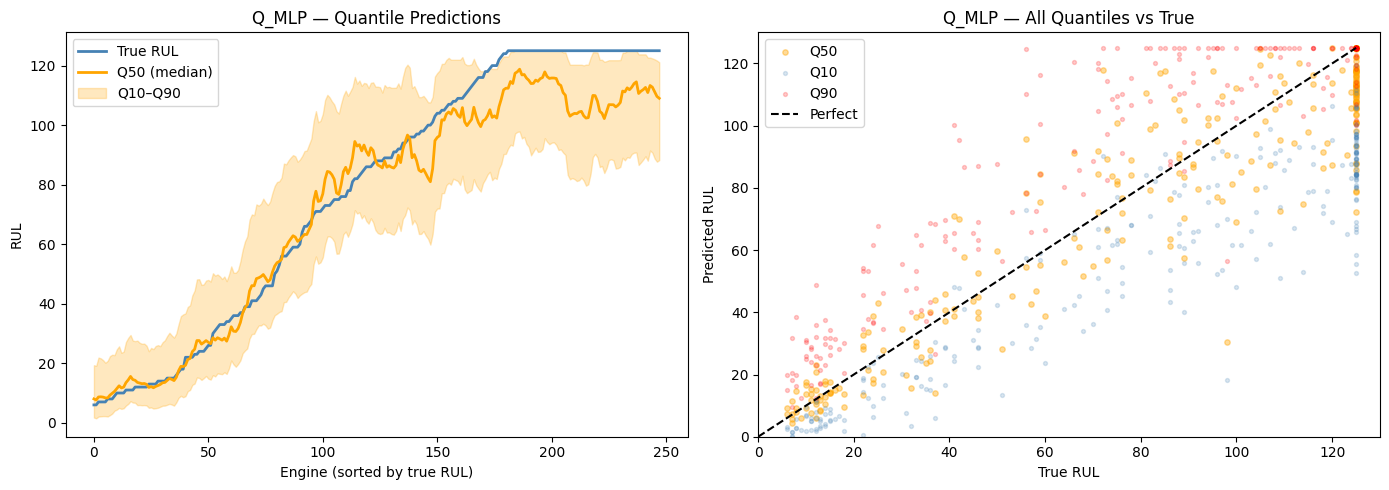

In [7]:
y_true, q10, q50, q90 = predict_quantiles(model, test_loader)
results, width, coverage = evaluate_quantile_model(y_true, q10, q50, q90, model_name='Q_MLP')
plot_quantile_predictions(y_true, q10, q50, q90, model_name='Q_MLP')

## 8. Calibration Metrics

Addresses critic: *'No calibration metrics — coverage probability, pinball loss missing'*


Pinball Loss by Quantile — Q_MLP
   Q10    Q50   Q90
2.5115 5.8581 2.237


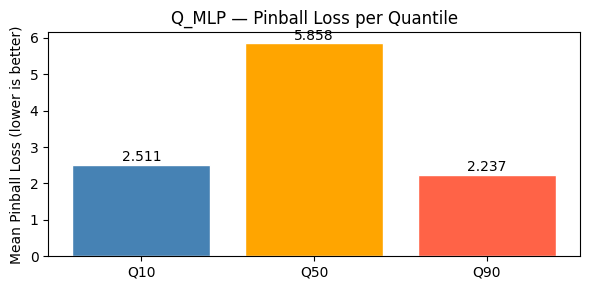

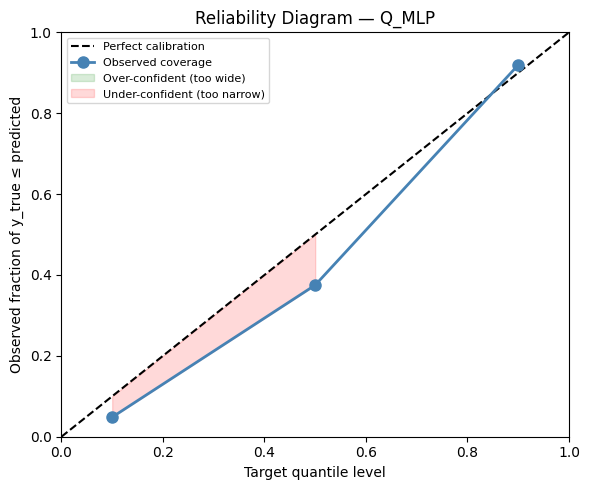

  Mean Calibration Error (MCE): 0.0653  (0=perfect, closer=better)

Interval Coverage by RUL Bucket — Q_MLP
RUL bucket  n_engines  coverage_%  mean_width  median_width
   [0, 25)         49       100.0       22.80         23.65
  [25, 50)         30        86.7       36.18         37.01
 [50, 100)         67        86.6       46.75         46.74
[100, 125)         35        80.0       41.09         38.22

Note: wider intervals in early life (RUL 50-125) reflect genuine
epistemic uncertainty — model has less certainty about long-horizon predictions.


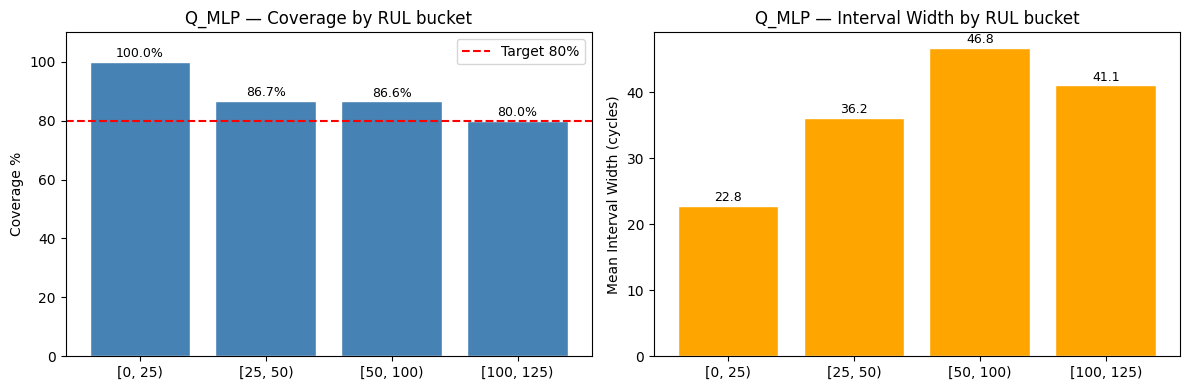

In [8]:
import numpy as np

# Pinball loss per quantile
preds_matrix = np.stack([q10, q50, q90], axis=1)
pinball_df = pinball_loss_by_quantile(y_true, preds_matrix, QUANTILES, model_name='Q_MLP')

# Reliability diagram
all_q_preds = {0.1: q10, 0.5: q50, 0.9: q90}
reliability_diagram(y_true, all_q_preds, title='Reliability Diagram — Q_MLP')

# Interval coverage by RUL bucket
bucket_df = interval_coverage_by_rul_bucket(y_true, q10, q90, model_name='Q_MLP')

## 9. Save Results to CSV

In [9]:
save_model_results(
    model_name = 'Q_MLP',
    model_type = 'quantile',
    y_true     = y_true,
    y_pred     = q50,
    q10        = q10,
    q90        = q90,
)
print('Results saved to results/all_model_results.csv')

  [Q_MLP] RMSE: 16.0724  |  NASA Score: 1085.90 (mean: 4.38)  |  R2: 0.8602  |  Bias: -4.50 (early ↓)
  → Saved to results/all_model_results.csv
Results saved to results/all_model_results.csv
